# ATF6-KO cardiac protein turnover — control vs ATF6-KO within each heart chamber

**Dataset:** `runs/timeseries_atf6` — the full ATF6 D₂O time-course (the complete set of which the
old `timeseries_dia` was the LV-control subset). A **4×5×2×3 factorial**: 4 heart chambers
(LA/RA/LV/RV) × 5 D₂O timepoints (1/3/7/10/14 d) × 2 conditions (control / ATF6-KO) × 3 biological
replicates = 120 mouse-heart DIA runs (DIA-NN 2.5.0), precursor RIA 4.6 %.

**Pipeline:** `integrate` (defaults: iso m0–m5, q<0.01, apex, 10 ppm) → `experiment = chamber`
relabel → `fit` (`deberneh_2025_rss`, `simple`, `hw`) → `rollup --model "linear simple"
--reference-condition control`. The rollup contrasts control vs ATF6-KO **within each chamber**
(Δk = k(ATF6-KO) − k(control); negative = KO turns the protein over *more slowly*).

This notebook covers:
1. **Study statistics & artifact audit** — the identification→fit→rollup funnel, reconciled against
   the files in `runs/timeseries_atf6/`.
2. **Per-chamber control-vs-KO** (task 3) — the shipped single-factor linear-simple Δk.
3. **Two-factor chamber×condition** (task 4) — a joint fit giving per-chamber Δk *and* an
   interaction test ("does the KO effect differ across chambers?").

**All headline results use `wls`** (the default weighting): `runs/timeseries_atf6/riana_rollup_*.txt`
and the curve PDFs are `# linear_weights wls`, and the two-factor fit below uses the same wls IRLS
weight. The `wls` vs `wls-var` comparison (§4) is the *only* place `wls-var` appears (read from the
`wlsvar/` subdir); the full method study is `reports/2026-07-24_linear_wls_per_point_var.md`.

## Methods & data provenance

**Animals / labeling.** Mouse hearts, metabolic D₂O labeling; precursor enrichment (RIA) **4.6 %**.
Design: 4 organism parts (chambers) — left/right atrium (LA/RA), left/right ventricle (LV/RV) — ×
5 labeling timepoints (**1, 3, 7, 10, 14 days**) × 2 conditions (**control**, **ATF6-KO**) × 3
biological replicates = **120 DIA runs** (Q Exactive HF, HCD, data-independent acquisition). SDRF:
`data/timeseries_atf6/samplesheet_atf6.sdrf.tsv`.

**Design note — the study is cross-sectional, not longitudinal.** Each mouse (`characteristics
[individual]`) is one `(condition, timepoint)` sacrificed animal, sampled in all 4 chambers; D₂O
turnover cannot re-sample a heart over time. `characteristics[biological replicate]` is therefore just
the **animal's 1/2/3 index within its `(condition, timepoint)` group** (constant across that animal's 4
chambers) — biorep 1 at day 1 and biorep 1 at day 14 are *different* animals, **not a paired series**.
Riana uses `biological_replicate` only as a within-`(experiment, condition, timepoint)` grouping key to
collapse an animal's peptides before treating animals as replicate points; no step pairs or blocks on
biorep across timepoints (the fit has no biorep term).

**Identification & quantification (upstream, quantms bigbio/quantmsdiann → DIA-NN 2.5.0).** DIA-NN
**library-free** workflow (`speclib=null`), against `uniprot_mouse_reviewed.fasta`: an in-silico
spectral library is **predicted from the FASTA by DIA-NN's own deep-learning predictor**
(`INSILICO_LIBRARY_GENERATION`: `--fasta-search --gen-spec-lib --predictor`; trypsin `K*,R*,!*P`,
≤2 missed cleavages, peptides 6–40 aa, charge 2–4, precursor m/z 400–2400, ≤3 variable mods) — **not
Prosit** (no Prosit/oktoberfest step in the pipeline). A preliminary pass then refines it into a
data-derived **empirical library** (`ASSEMBLE_EMPIRICAL_LIBRARY` → `empirical_library.parquet`,
`skip_preliminary_analysis=false`), used for the `FINAL_QUANTIFICATION`. Fixed **Carbamidomethyl (C,
+57.021)**, variable **Oxidation (M, +15.995)**; MS1 mass accuracy 10 ppm (auto-optimised); peptidoform
scoring on; precursor/protein matrices at **1 % FDR** (`--pg-level 2`). Output `diann_report.parquet`
(the intake Riana reads).

**Isotopomer integration (`riana integrate`).** MS1 XIC of isotopomers **m0–m5** per identified
precursor, PSMs at **q < 0.01**, ±10 ppm windows (from the SDRF), apex-anchored, 0.15 min integration
half-width — current DIA-NN-intake defaults. One `_riana.txt` per run + a manifest.

**Experiment stratification.** `experiment` is set to the **chamber** (via
`integrate --experiment-column "characteristics[organism part]"`; here applied as a manifest relabel
since the run predates the flag) so Riana groups on `(experiment=chamber, condition)` and the Δk is
control-vs-ATF6-KO **within each chamber** (not pooled across chambers, which would fraction-collapse
a mouse's 4 chambers into one cell).

**Kinetic fit (`riana fit`).** Model **`simple`** (one-exponent D₂O), label **`hw`**, coefficient
table **`deberneh_2025_rss`** (in-vivo mouse per-AA table; the shipped 1.1.0 D₂O default). Per-curve
= `(chamber, condition)`; a peptidoform is fit on ≥ **3** distinct timepoints (`--depth 3`), must carry
≥ **8** labeling sites (`--min-spep 8`, the hw default), and per-timepoint FS points outside
[−0.05, 1.05] are dropped as failed solves (`--fs-rail-drop`). Fraction-new (θ) with a residual-
bootstrap prediction interval is written to `riana_fit_fractions.txt`; per-peptidoform k to
`riana_fit_peptides.txt`.

**Protein roll-up (`riana rollup --model "linear simple"`).** Per protein, per chamber, the two
conditions are fit **jointly** in φ = log(1 − θ) space (through the origin, `φ ~ 0 + day:C(condition)`)
with **WLS** (delta-method weight `(1 − θ̂)²`; the default), giving a per-condition k and a Δk =
k(ATF6-KO) − k(control) contrast. Curation before the fit: **unique** parsimony (only single-accession
peptides), peptide admission **`all`** (a peptide must pass the gate in *both* conditions — the paired
Δk basis), R² ≥ **0.8** OR the flat-curve k_cv rescue, ≥ **2** attributed peptides, ≥ **3** collapsed
timepoints. Benjamini-Hochberg is applied **per experiment** (each chamber its own family). Reference
condition = **control**. Outputs `riana_rollup_proteins.txt` (per-condition k + Δk/p/p_adj),
`riana_rollup_fractions.txt` (collapsed θ substrate), and the `--plot` curve PDFs.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
plt.rcParams['figure.dpi'] = 100
RUN = Path('../runs/timeseries_atf6')
DATA = Path('../data/timeseries_atf6')

proteins = pd.read_csv(RUN/'riana_rollup_proteins.txt', sep='\t', comment='#')
fractions = pd.read_csv(RUN/'riana_rollup_fractions.txt', sep='\t', comment='#')

# gene / description annotation
desc = pd.read_csv(DATA/'quantms_results/quant_tables/diann_report.protein_description.tsv', sep='\t')
GENE = dict(zip(desc['Protein.Id'], desc['Gene']))
DESCR = dict(zip(desc['Protein.Id'], desc['Description']))
def gene(acc): return GENE.get(acc, acc)

CHAMBERS = ['LA','RA','LV','RV']
NAMES = {'LA':'Left atrium','RA':'Right atrium','LV':'Left ventricle','RV':'Right ventricle'}
print('rollup proteins rows:', len(proteins), '| chambers:', sorted(proteins.experiment.unique()))
print('conditions:', sorted(proteins.condition.unique()))
proteins.head(3)

rollup proteins rows: 7224 | chambers: ['LA', 'LV', 'RA', 'RV']
conditions: ['ATF6-KO', 'control']


,experiment,condition,protein,method,n_peptides,n_points,n_mbr,n_metox,n_clean,k_deg,ci_lo,ci_hi,R_squared,peptide_median_k,delta_k,delta_k_se,delta_k_p,delta_k_p_adj
0,LA,ATF6-KO,A2AAJ9,linear simple,29,15,0,0,328,0.077622,0.071965,0.083280,0.982272,0.075972,-0.001395,0.003978,0.728557,0.886010
1,LA,ATF6-KO,A2AMM0,linear simple,3,15,0,0,33,0.059386,0.052552,0.066221,0.956849,0.044624,0.001620,0.004702,0.732926,0.886010
2,LA,ATF6-KO,A2AQ07,linear simple,2,10,0,0,13,0.118125,0.083733,0.152518,0.869362,0.204721,0.017202,0.019910,0.397841,0.672557


## 1. Study statistics & artifact audit

The identification→integration→fit→roll-up funnel, computed **directly from the files in
`runs/timeseries_atf6/`** (and the upstream `diann_report.parquet`) so the numbers are auditable and
stay in sync with the artifacts. The final cell asserts the key invariants — it will fail loudly if
the artifacts are regenerated with different settings.

In [2]:
import pyarrow.parquet as pq

# --- upstream DIA-NN identifications (the intake Riana reads; run-level q < 0.01) ---
dia = pq.read_table(DATA/'quantms_results/quant_tables/diann_report.parquet',
    columns=['Run','Q.Value','Stripped.Sequence','Modified.Sequence','Precursor.Id',
             'Protein.Group']).to_pandas()
dia = dia[dia['Q.Value'] <= 0.01]
n_runs = dia.Run.nunique()

# --- Riana fit outputs ---
fp = pd.read_csv(RUN/'riana_fit_peptides.txt', sep='\t', comment='#')
ff = pd.read_csv(RUN/'riana_fit_fractions.txt', sep='\t', comment='#')
gate = (fp['R_squared'] >= 0.8) | ((fp['R_squared'] >= 0.6) & (fp['k_cv'] < 0.2))

funnel = pd.DataFrame([
    ('DIA-NN runs',                                    n_runs),
    ('DIA-NN precursors (q<0.01)',                     dia['Precursor.Id'].nunique()),
    ('DIA-NN peptides (stripped seq)',                 dia['Stripped.Sequence'].nunique()),
    ('DIA-NN protein groups',                          dia['Protein.Group'].nunique()),
    ('Riana peptidoforms integrated (fraction curves)',ff['concat'].nunique()),
    ('Riana proteins with ≥1 peptidoform',             ff['protein id'].nunique()),
    ('Riana peptidoforms fit (any chamber×cond)',      fp['concat'].nunique()),
    ('Riana curve-fits = chamber×cond×peptidoform',    len(fp)),
    ('  ... with a finite k',                          int(fp['k_deg'].notna().sum())),
    ('  ... passing curation (R²≥0.8 ∨ k_cv rescue)',  int(gate.sum())),
    ('Rollup proteins (union over chambers)',          proteins['protein'].nunique()),
], columns=['stage', 'count'])
print(funnel.to_string(index=False))

                                          stage  count
                                    DIA-NN runs    120
                     DIA-NN precursors (q<0.01)  52647
                 DIA-NN peptides (stripped seq)  46011
                          DIA-NN protein groups   5987
Riana peptidoforms integrated (fraction curves)  33329
             Riana proteins with ≥1 peptidoform   4679
      Riana peptidoforms fit (any chamber×cond)  38404
    Riana curve-fits = chamber×cond×peptidoform 236515
                            ... with a finite k 190169
    ... passing curation (R²≥0.8 ∨ k_cv rescue)  70609
          Rollup proteins (union over chambers)   1284


In [3]:
# --- per-experiment roll-up: proteins compared (both conditions, Δk) + positive hit rate ---
pairs0 = proteins.dropna(subset=['delta_k']).drop_duplicates(['experiment', 'protein'])
rows = []
for ch in CHAMBERS:
    e = proteins[proteins.experiment == ch]
    comp = pairs0[pairs0.experiment == ch]
    n_kdeg = e.dropna(subset=['k_deg']).protein.nunique()   # proteins with a k in ≥1 condition
    n_comp = comp.protein.nunique()                          # proteins with a Δk (both conditions)
    n_sig = int((comp.delta_k_p_adj < 0.05).sum())
    rows.append(dict(chamber=NAMES[ch], proteins_with_k=n_kdeg, compared_delta_k=n_comp,
                     significant=n_sig, hit_rate_pct=round(100 * n_sig / n_comp, 2)))
per_exp = pd.DataFrame(rows).set_index('chamber')
per_exp.loc['ALL'] = [per_exp.proteins_with_k.sum(), per_exp.compared_delta_k.sum(),
                      per_exp.significant.sum(),
                      round(100 * per_exp.significant.sum() / per_exp.compared_delta_k.sum(), 2)]
per_exp

,proteins_with_k,compared_delta_k,significant,hit_rate_pct
chamber,,,,
Left atrium,1059.0,1016.0,18.0,1.77
Right atrium,1046.0,992.0,2.0,0.20
Left ventricle,837.0,780.0,9.0,1.15
Right ventricle,772.0,722.0,8.0,1.11
ALL,3714.0,3510.0,37.0,1.05


In [4]:
# --- AUDIT: assert the reported numbers match the artifacts / expected design ---
# provenance: the canonical artifacts are wls (not wls-var)
hdr = (RUN/'riana_rollup_proteins.txt').read_text().splitlines()
assert any(l.strip() == '# linear_weights wls' for l in hdr[:40]), 'canonical rollup is not wls!'
assert any(l.strip() == '# model linear simple' for l in hdr[:40])
# design shape
assert n_runs == 120, n_runs
assert sorted(fp.experiment.unique()) == ['LA', 'LV', 'RA', 'RV']
assert sorted(fp.condition.unique()) == ['ATF6-KO', 'control']
assert sorted(ff.labeling_time.unique()) == [1, 3, 7, 10, 14]
assert sorted(ff.biological_replicate.unique()) == [1, 2, 3]
# funnel monotonicity where it must hold
assert int(fp['k_deg'].notna().sum()) <= len(fp)
assert int(gate.sum()) <= int(fp['k_deg'].notna().sum())
# per-experiment compared counts reconcile with the volcano/§2 figures
assert per_exp.loc['Left atrium', 'compared_delta_k'] ==        proteins[(proteins.experiment=='LA')].dropna(subset=['delta_k']).protein.nunique()
# significant total matches the wls vs wls-var recap (§4)
assert int(per_exp.loc['ALL', 'significant']) ==        int((proteins.dropna(subset=['delta_k']).drop_duplicates(['experiment','protein']).delta_k_p_adj < 0.05).sum())
print('AUDIT PASSED — reported statistics match runs/timeseries_atf6 artifacts (wls).')

AUDIT PASSED — reported statistics match runs/timeseries_atf6 artifacts (wls).


**Reading the funnel.** DIA-NN identifies ~46 k peptides / ~6 k protein groups across the 120 runs;
Riana integrates the isotopomer envelope for the subset it can mass-and-extract, fits a D₂O curve per
`(chamber, condition)` for those meeting the site/timepoint floors (`--min-spep 8`, `--depth 3`), and
the roll-up keeps only unique-attribution proteins with ≥ 2 curated peptides present in **both**
conditions of a chamber. The **positive hit rate** is the fraction of compared proteins with a
significant Δk (per-experiment BH, p_adj < 0.05) — low (0.2–1.8 %) and chamber-uneven, consistent with
a subtle, largely chamber-uniform ATF6-KO effect on a gappy DIA substrate (median ~3 usable
timepoints/peptide; see §4).

## 2. Per-chamber control vs ATF6-KO (shipped linear-simple Δk)

In [5]:
# one Δk per (chamber, protein)
pairs = proteins.dropna(subset=['delta_k']).drop_duplicates(['experiment','protein']).copy()
summary = pairs.groupby('experiment').agg(
    n_proteins=('protein','nunique'),
    sig_padj05=('delta_k_p_adj', lambda s:int((s<0.05).sum())),
    median_dk=('delta_k','median'),
    frac_slower_in_KO=('delta_k', lambda s: float((s<0).mean())),
).reindex(CHAMBERS)
summary['chamber'] = [NAMES[c] for c in summary.index]
summary

,n_proteins,sig_padj05,median_dk,frac_slower_in_KO,chamber
experiment,,,,,
LA,1016,18,-0.004446,0.756890,Left atrium
RA,992,2,-0.003341,0.713710,Right atrium
LV,780,9,-0.002131,0.733333,Left ventricle
RV,722,8,-0.002209,0.722992,Right ventricle


Δk = k(ATF6-KO) − k(control). The median Δk is **negative in every chamber** — across the
proteome, ATF6-KO shifts turnover *slower* (a broad brake on protein clearance), most pronounced by
median magnitude in the atria. The number of *individually*-significant proteins (per-experiment BH)
is modest and uneven across chambers (LA highest, RA lowest — likely a depth/data-quality difference
more than a biological one), reflecting DIA curve gappiness (median ~3 usable timepoints/peptide).

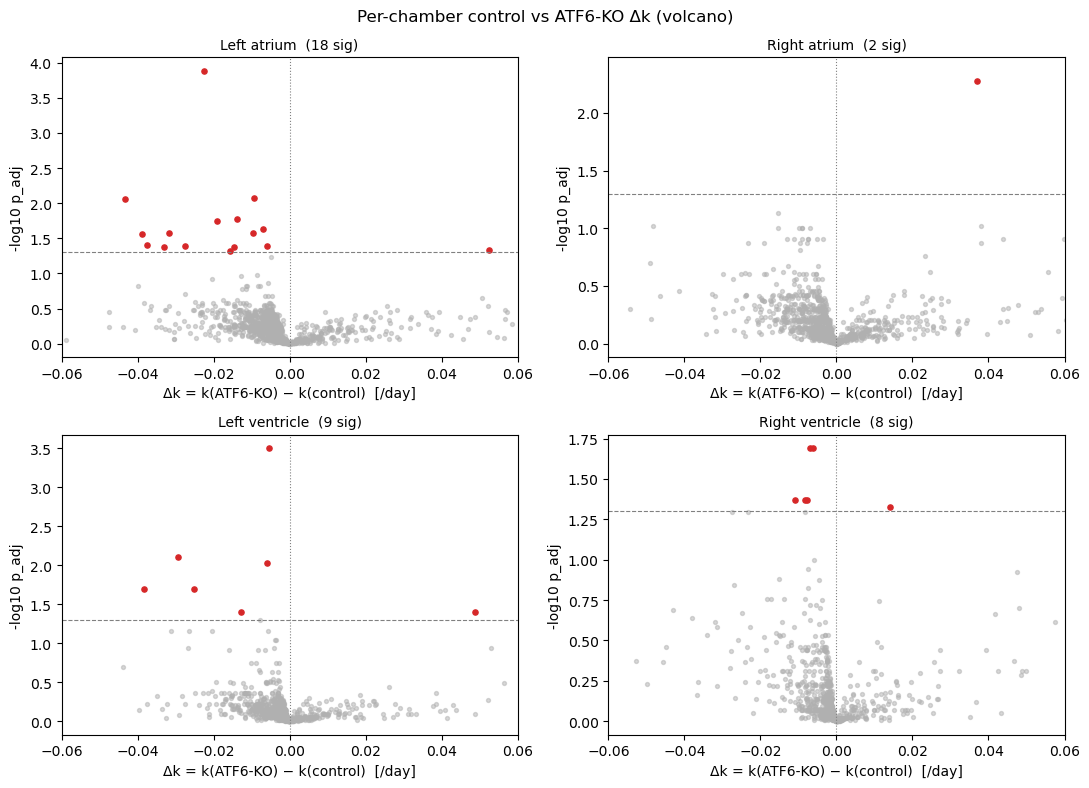

In [6]:
# per-chamber volcano: Δk vs -log10(p_adj)
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, ch in zip(axes.ravel(), CHAMBERS):
    s = pairs[pairs.experiment==ch]
    y = -np.log10(s['delta_k_p_adj'].clip(lower=1e-300))
    sig = s['delta_k_p_adj'] < 0.05
    ax.scatter(s.loc[~sig,'delta_k'], y[~sig], s=8, c='#b0b0b0', alpha=0.5)
    ax.scatter(s.loc[sig,'delta_k'], y[sig], s=14, c='#d62728')
    ax.axhline(-np.log10(0.05), ls='--', c='grey', lw=0.8)
    ax.axvline(0, ls=':', c='grey', lw=0.8)
    ax.set_title(f'{NAMES[ch]}  ({sig.sum()} sig)', fontsize=10)
    ax.set_xlabel('Δk = k(ATF6-KO) − k(control)  [/day]'); ax.set_ylabel('-log10 p_adj')
    ax.set_xlim(-0.06, 0.06)
fig.suptitle('Per-chamber control vs ATF6-KO Δk (volcano)', fontsize=12)
fig.tight_layout(); plt.show()

In [7]:
# top significant hits per chamber, annotated with gene names
for ch in CHAMBERS:
    s = pairs[(pairs.experiment==ch) & (pairs.delta_k_p_adj<0.05)].sort_values('delta_k_p_adj')
    if not len(s):
        print(f'{NAMES[ch]}: no proteins at p_adj<0.05'); continue
    t = s[['protein','delta_k','delta_k_p_adj']].head(8).copy()
    t.insert(1,'gene',[gene(a) for a in t.protein])
    print(f'\n=== {NAMES[ch]} — top {min(8,len(s))} of {len(s)} significant ===')
    print(t.to_string(index=False))


=== Left atrium — top 8 of 18 significant ===
protein   gene   delta_k  delta_k_p_adj
 P97443  Smyd1 -0.022423       0.000131
 O88543  Cops3 -0.178789       0.008424
 Q99MN9   Pccb -0.009472       0.008424
 P97447   Fhl1 -0.043431       0.008681
 Q3TBW2 Mrpl10 -0.013859       0.016545
 P56375  Acyp2 -0.019045       0.018105
 Q9DB20 Atp5po -0.006921       0.023448
 P80318   Cct3 -0.031662       0.026699

=== Right atrium — top 2 of 2 significant ===
protein gene  delta_k  delta_k_p_adj
 Q9Z0E6 Gbp2 0.089363       0.004323
 Q9Z1Z0 Uso1 0.036968       0.005320

=== Left ventricle — top 8 of 9 significant ===
protein     gene   delta_k  delta_k_p_adj
 Q9QXX4 Slc25a13 -0.005534       0.000317
 P48774    Gstm5 -0.029414       0.007889
 Q91WD5   Ndufs2 -0.006007       0.009435
 P23116    Eif3a -0.038186       0.020402
 Q9JJZ2    Tuba8 -0.025138       0.020402
 Q9WVE8  Pacsin2  0.089343       0.026695
 Q02248   Ctnnb1  0.048771       0.039547
 Q9CPY7     Lap3 -0.012707       0.039547

=== Rig

### Example φ-space curves for strong hits (inline `plot_linear`)

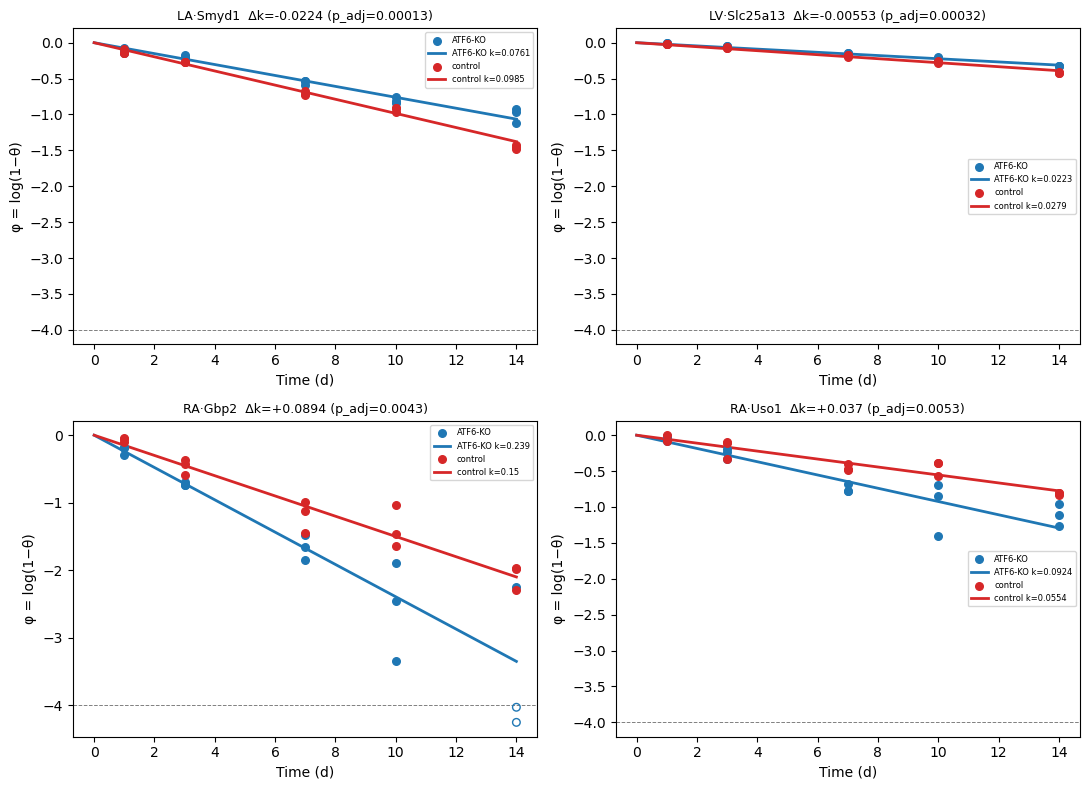

In [8]:
_COL = ['#1f77b4','#d62728','#2ca02c','#9467bd']
def to_phi(theta, floor=0.001, ceil=0.999):
    t = np.clip(np.asarray(theta,float), floor, ceil); return np.log(1-t)

def plot_linear(ax, exp, prot, phi_limit=-4.0):
    fr = fractions[(fractions.experiment==exp)&(fractions.protein==prot)]
    pr = proteins[(proteins.experiment==exp)&(proteins.protein==prot)]
    tmax = 0
    for i,(cond,sub) in enumerate(fr.groupby('condition')):
        sub = sub.sort_values('labeling_time'); col=_COL[i%len(_COL)]
        t=sub.labeling_time.to_numpy(); phi=to_phi(sub.fs.to_numpy()); keep=phi>phi_limit
        tmax=max(tmax, t.max() if len(t) else 0)
        ax.scatter(t[keep],phi[keep],s=30,color=col,label=cond,zorder=3)
        ax.scatter(t[~keep],phi[~keep],s=30,facecolors='none',edgecolors=col,zorder=3)
        row=pr[pr.condition==cond]
        if len(row):
            k=float(row.k_deg.iloc[0]); g=np.linspace(0,tmax,50)
            ax.plot(g,-k*g,color=col,lw=2,label=f'{cond} k={k:.3g}')
    ax.axhline(phi_limit,ls='--',c='grey',lw=0.7)
    r=pr.drop_duplicates('protein').iloc[0]
    ax.set_title(f'{exp}·{gene(prot)}  Δk={r.delta_k:+.3g} (p_adj={r.delta_k_p_adj:.2g})',fontsize=9)
    ax.set_xlabel('Time (d)'); ax.set_ylabel('φ = log(1−θ)'); ax.legend(fontsize=6)

# the two most significant hits overall
top = pairs.sort_values('delta_k_p_adj').head(4)
fig, axes = plt.subplots(2,2,figsize=(11,8))
for ax,(_,r) in zip(axes.ravel(), top.iterrows()):
    plot_linear(ax, r.experiment, r.protein)
fig.tight_layout(); plt.show()

## 3. Two-factor model — chamber × condition (task 4)

The shipped linear-simple model already fits a protein's cells **jointly** with one shared residual
variance (`φ ~ 0 + day:C(cell)`); it just reports a single pairwise Δk. Crossing the two factors
into an 8-level `chamber|condition` cell factor lets the *same* estimator yield, per protein:

- **per-chamber Δk** = slope[chamber|control] − slope[chamber|ATF6-KO]  (k = −slope), and
- an **interaction F-test**: are the four per-chamber Δk equal? (does the KO effect differ by chamber?)

This is a contrast/reporting layer over the existing estimator — not a new model. Below, the joint
per-chamber Δk is checked against the shipped per-chamber (separate-fit) rollup, then the interaction
is tested.

In [9]:
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

# long substrate = the already-collapsed rollup fractions (experiment=chamber)
long = fractions.rename(columns={'experiment':'chamber','fs':'theta'})
REF, TEST = 'control', 'ATF6-KO'; PHI=-4.0

def cells_of(grp):
    out={}
    for (ch,cond),cg in grp.groupby(['chamber','condition']):
        t=cg.labeling_time.to_numpy(float); phi=to_phi(cg.theta.to_numpy())
        m=np.isfinite(phi)&(phi>PHI)&(t>0)
        if m.sum()>=2: out[(ch,cond)]=(t[m],phi[m])
    return out

dk_rows, inter_rows = [], []
for prot, grp in long.groupby('protein'):
    cells = cells_of(grp)
    if sum(len(t) for t,_ in cells.values())<3: continue
    fit_df = pd.DataFrame({
        'day': np.concatenate([t for t,_ in cells.values()]),
        'phi': np.concatenate([p for _,p in cells.values()]),
        'cell': np.concatenate([[f'{ch}|{c}']*len(t) for (ch,c),(t,_) in cells.items()])})
    try:
        res = smf.ols('phi ~ 0 + day:C(cell)', data=fit_df).fit()
        w = np.exp(2*np.maximum(res.fittedvalues.to_numpy(), PHI))
        res = smf.wls('phi ~ 0 + day:C(cell)', data=fit_df, weights=w).fit()
    except Exception: continue
    names=list(res.params.index); cn=lambda ch,c: f'day:C(cell)[{ch}|{c}]'
    paired=[ch for ch in CHAMBERS if cn(ch,REF) in names and cn(ch,TEST) in names]
    dks={}
    for ch in paired:
        c=np.zeros(len(names)); c[names.index(cn(ch,REF))]=1; c[names.index(cn(ch,TEST))]=-1
        tt=res.t_test(c); dk=float(np.ravel(tt.effect)[0]); dks[ch]=dk
        dk_rows.append(dict(protein=prot,chamber=ch,delta_k=dk,
                            delta_k_se=float(np.ravel(tt.sd)[0]),delta_k_p=float(np.ravel(tt.pvalue)[0])))
    if len(paired)>=2:
        L=[]; r0=paired[0]
        for ch in paired[1:]:
            row=np.zeros(len(names))
            row[names.index(cn(r0,REF))]+=1; row[names.index(cn(r0,TEST))]-=1
            row[names.index(cn(ch,REF))]-=1; row[names.index(cn(ch,TEST))]+=1
            L.append(row)
        try:
            ft=res.f_test(np.array(L))
            inter_rows.append(dict(protein=prot,n_chambers=len(paired),
                interaction_p=float(ft.pvalue), dk_spread=max(dks.values())-min(dks.values()),
                **{f'dk_{c}':dks.get(c,np.nan) for c in CHAMBERS}))
        except Exception: pass

dk = pd.DataFrame(dk_rows); inter = pd.DataFrame(inter_rows)
for ch,sub in dk.groupby('chamber'):
    m=sub.delta_k_p.notna(); dk.loc[sub.index[m],'delta_k_p_adj']=multipletests(sub.loc[m,'delta_k_p'],method='fdr_bh')[1]
inter['interaction_p_adj']=multipletests(inter.interaction_p,method='fdr_bh')[1]
print(f'two-factor: {dk.protein.nunique()} proteins, {len(inter)} testable for interaction')

two-factor: 1207 proteins, 982 testable for interaction


In [10]:
# per-chamber Δk from the joint fit should match the shipped separate-fit rollup
chk = dk.merge(pairs, left_on=['chamber','protein'], right_on=['experiment','protein'],
               suffixes=('_joint','_sep'))
from scipy.stats import pearsonr
print('per-chamber Δk: joint (shared-variance) vs separate (per-chamber) rollup')
print(f'  Pearson r = {pearsonr(chk.delta_k_joint, chk.delta_k_sep)[0]:.4f}  (should be ~1 — same points)')
print(f'  median |Δ| = {(chk.delta_k_joint-chk.delta_k_sep).abs().median():.6f}')
print('\nsignificant per-chamber Δk (p_adj<0.05), joint vs separate BH:')
print(pd.DataFrame({
    'joint(shared-var)':  dk[dk.delta_k_p_adj<0.05].groupby('chamber').protein.nunique().reindex(CHAMBERS),
    'separate(per-strat)':pairs[pairs.delta_k_p_adj<0.05].groupby('experiment').protein.nunique().reindex(CHAMBERS),
}))

per-chamber Δk: joint (shared-variance) vs separate (per-chamber) rollup
  Pearson r = 1.0000  (should be ~1 — same points)
  median |Δ| = 0.000000

significant per-chamber Δk (p_adj<0.05), joint vs separate BH:
    joint(shared-var)  separate(per-strat)
LA                 30                   18
RA                  9                    2
LV                  6                    9
RV                 21                    8


The joint per-chamber Δk match the separate-fit rollup (same collapsed points); the estimator
is identical — what the two-factor framing *adds* is (a) the shared-variance pooling (which shifts
power) and (b) the interaction test below.

In [11]:
# interaction: which proteins respond to ATF6-KO differently across chambers?
sig_int = inter[inter.interaction_p_adj<0.05].sort_values('interaction_p')
print(f'proteins with a significant chamber×condition interaction (p_adj<0.05): {len(sig_int)}')
show = sig_int.head(10).copy(); show.insert(1,'gene',[gene(a) for a in show.protein])
print(show[['protein','gene','interaction_p_adj','dk_spread','dk_LA','dk_RA','dk_LV','dk_RV']].to_string(index=False))

proteins with a significant chamber×condition interaction (p_adj<0.05): 2
protein  gene  interaction_p_adj  dk_spread     dk_LA     dk_RA     dk_LV     dk_RV
 O88543 Cops3           0.000222   0.179638 -0.178789 -0.005811  0.000849 -0.023572
 P97443 Smyd1           0.003437   0.022158 -0.022423 -0.004123 -0.000265 -0.007575


**Almost all proteins respond to ATF6-KO consistently across chambers** — only a handful show a
significant chamber×condition interaction. Those are the genuinely *chamber-specific* responders.
The clearest is **O88543 (Cops3, COP9 signalosome subunit 3)** and **P97443 (Smyd1, a cardiac
histone-lysine methyltransferase)** — plotted per chamber below.

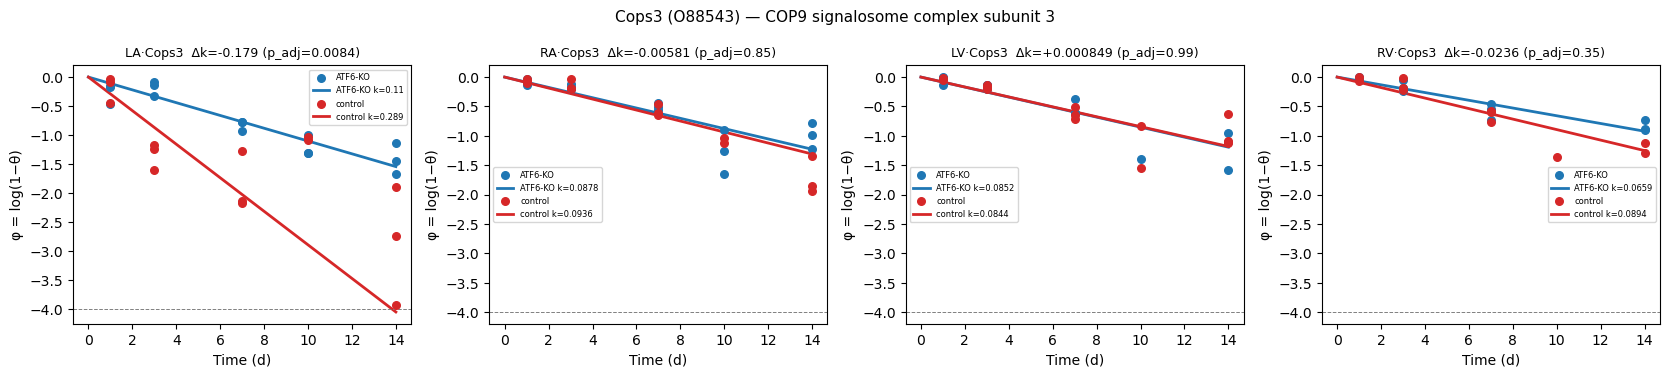

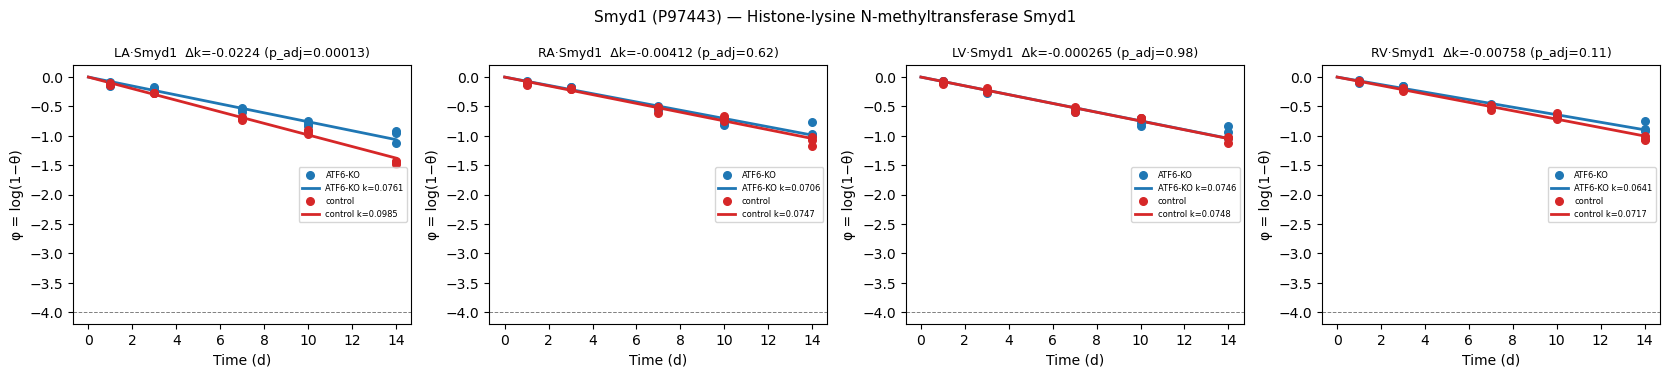

In [12]:
for prot in ['O88543','P97443']:
    chs = [c for c in CHAMBERS if len(proteins[(proteins.experiment==c)&(proteins.protein==prot)])]
    fig, axes = plt.subplots(1, len(chs), figsize=(4.2*len(chs), 3.8))
    axes = np.atleast_1d(axes)
    for ax,ch in zip(axes, chs): plot_linear(ax, ch, prot)
    fig.suptitle(f'{gene(prot)} ({prot}) — {DESCR.get(prot,"")}', fontsize=11)
    fig.tight_layout(); plt.show()

## 4. `wls` vs `wls-var` on this dataset (recap)

Full analysis in `reports/2026-07-24_linear_wls_per_point_var.md` (2026-08-09 update). Headline on
atf6 (strongly heteroscedastic, SD(log σ)=0.91, but low df, median ~3 tp/peptide):
- `k_deg` essentially unchanged (Pearson 0.99);
- significant per-chamber Δk rises **37 → 65** (per-experiment BH; near-superset, +29, 1 lost);
- biorep leave-one-out reproducibility **improves** under `wls-var` (k CV −1.8 %, Δk sign-consistency
  +2.5 pp) → the extra sensitivity is real power, not Type-I inflation. Gain tracks curve df, so DIA
  gappiness caps it between the sparse-DIA (+2 %) and rich-timeseries (+10 %) points.

In [13]:
wls = proteins; var = pd.read_csv(RUN/'wlsvar/riana_rollup_proteins.txt', sep='\t', comment='#')
m = wls.merge(var, on=['experiment','condition','protein'], suffixes=('_wls','_var')).drop_duplicates(['experiment','protein'])
sw = m.delta_k_p_adj_wls<0.05; sv = m.delta_k_p_adj_var<0.05
print(pd.DataFrame({'wls':[int(sw.sum())],'wls-var':[int(sv.sum())],
                    'both':[int((sw&sv).sum())],'wls-only':[int((sw&~sv).sum())],'var-only':[int((~sw&sv).sum())]},
                   index=['significant per-chamber Δk (p_adj<0.05)']))

                                         wls  wls-var  both  wls-only  \
significant per-chamber Δk (p_adj<0.05)   37       65    36         1   

                                         var-only  
significant per-chamber Δk (p_adj<0.05)        29  


## 5. Biological synthesis

- **Global brake on turnover under ATF6-KO.** Median Δk is negative in all four chambers — losing
  ATF6 (an ER-stress / UPR transcription factor) slows bulk cardiac protein clearance, most
  strongly in the atria. This is the dominant, chamber-consistent signal.
- **The KO effect is largely chamber-uniform.** The two-factor interaction test finds only a
  handful of proteins whose turnover response differs by chamber — so a single, pooled "ATF6-KO
  effect" is a defensible summary for most of the proteome, and the per-chamber split mostly buys
  spatial resolution of *magnitude*, not distinct programs.
- **A few genuinely chamber-specific responders** stand out — notably **Cops3** and the
  cardiac-specific chromatin regulator **Smyd1** (e.g. Smyd1's KO effect concentrated in one
  chamber). These interaction hits are the candidates for chamber-specific ATF6 biology and warrant
  orthogonal follow-up.
- **Method note:** `wls-var` recovers ~2× the significant Δk calls at no reproducibility cost, but
  the extra calls outrun the point-reproducibility gain — treat them as power-recovered, still worth
  confirmation. `wls` remains the safe default.

*Prototype provenance:* the two-factor fit and the φ-plot inlined here are the working prototypes
(`scratchpad/two_factor.py`, `scratchpad/rollup_plot.py`) slated to be wired into `riana.core` /
`rollup --plot` in the ship step.